# OR Curvature Analysis on Oversquashing-prone Graphs

## 1. Utils

### 1.1 Imports

In [99]:
# system
import os

# GraphRicciCurvature/NetworKit and PyTorch can both initialize OpenMP on macOS.
# These must be set before importing torch, numpy, scipy, or GraphRicciCurvature.
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("VECLIB_MAXIMUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")
os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/matplotlib-cache")

import sys
from pathlib import Path

# scientific standard libraries
import numpy as np
import pandas as pd

# visuals
import seaborn as sns
import matplotlib.pyplot as plt
import networkx as nx

# torch
import torch
import torch_geometric
from torch_geometric.utils import to_networkx

# project paths
working_directory = Path("/Users/luigifracassetti/projects/neural-sheaf-diffusion")
quick_analysis_directory = working_directory / "quick_analysis"
for directory in (working_directory, quick_analysis_directory):
    directory_string = str(directory)
    if directory_string not in sys.path:
        sys.path.insert(0, directory_string)

# experimental naive graph generating class
from lf_bottleneck_graphs import BottleneckGraphGenerator, BottleneckGraphConfig
import re
import shlex
import subprocess
from tempfile import TemporaryDirectory
from types import SimpleNamespace


### 1.2 Toy Data and Visuals

In [100]:
# example loading
data_path = Path("/Users/luigifracassetti/projects/neural-sheaf-diffusion/datasets/synthetic_exp/processed/data.pt")
data, _ = torch.load(data_path, weights_only=False)

# example display
print(f"Raw PyG data: {data}\n")

# subdivide
nodes_features = data.x
nodes_connectivity = data.edge_index
node_classes = data.y

# exploring
# nodes features
print(f"Node features:\n{nodes_features}")
print(f"Node features size:\n{nodes_features.shape}\n")

# nodes classes
print(f"Nodes classes:\n{node_classes}")
print(f"Nodes classes size:\n{node_classes.shape}\n")

# nodes connectivity
print(f"Nodes connectivity:\n{nodes_connectivity}")
print(f"Nodes connectivity size:\n{nodes_connectivity.shape}\n")


Raw PyG data: Data(x=[250, 32], edge_index=[2, 496], y=[250])

Node features:
tensor([[ 9.2300e-01,  8.9871e-02, -1.3293e-01,  ...,  3.8723e-09,
         -1.5261e-09,  1.4772e-11],
        [-4.1642e-01,  7.3120e-02,  2.1559e-01,  ..., -8.5053e-07,
          1.9279e-08,  8.9577e-08],
        [ 8.6775e-02,  2.1087e-01,  4.8000e-02,  ..., -1.2757e-11,
         -2.8841e-12,  2.6393e-11],
        ...,
        [ 7.7190e-02,  2.7285e-01,  3.5086e-02,  ..., -1.3149e-10,
          8.1015e-11,  3.7219e-12],
        [-6.7201e-01, -1.1131e-01,  2.9399e-01,  ..., -1.5640e-12,
         -2.3014e-13,  2.3358e-13],
        [ 2.6484e-01,  3.1577e-01,  2.3331e-01,  ...,  1.3548e-10,
          1.2400e-11, -3.1839e-11]])
Node features size:
torch.Size([250, 32])

Nodes classes:
tensor([1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1,
        1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1,
        1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1

In [101]:
# new synthetic dataset generation
cfg = BottleneckGraphConfig(
    n_left=25,
    n_right=25,
    bridge_width=3,
    feature_dim=16,
    num_classes=2,
    seed=42
)

generator = BottleneckGraphGenerator(cfg)
data = generator.generate()

print(data)
print(f"nodes features {data.x}\n")
print(f"bottleneck {data.bottleneck}\n")
print(f"nodes classes {data.y}\n")

Data(edge_index=[2, 1206], bottleneck=[1206], num_nodes=50, x=[50, 16], y=[50], num_classes=2, bridge_width=3)
nodes features tensor([[ 1.5807e+00,  1.2695e+00,  8.4488e-01, -1.6762e+00,  7.5814e-01,
         -1.3407e+00,  3.3363e-02, -1.7983e+00, -1.1415e+00,  1.8976e+00,
         -6.1243e-01, -1.5539e+00, -1.0464e+00, -2.8734e-02, -1.0775e+00,
          6.4047e-01],
        [ 1.6985e+00,  1.3227e+00,  9.2022e-01, -1.9741e+00,  5.5642e-01,
         -9.3670e-01, -2.4657e-01, -1.7887e+00, -1.1029e+00,  1.6577e+00,
         -4.0835e-01, -1.2347e+00, -7.5233e-01, -9.8281e-02, -1.0650e+00,
          1.1083e+00],
        [ 2.2882e+00,  1.7014e+00,  1.4552e+00, -1.9747e+00,  7.6508e-01,
         -1.2839e+00, -3.0671e-01, -1.2852e+00, -7.9518e-01,  1.7797e+00,
         -3.7832e-01, -1.2970e+00, -5.8413e-01, -7.1986e-01, -1.3204e+00,
          5.7474e-01],
        [ 1.9296e+00,  1.4026e+00,  5.6555e-01, -2.2519e+00,  8.1247e-01,
         -1.1034e+00,  2.4223e-01, -1.5918e+00, -5.6615e-01,  1.5

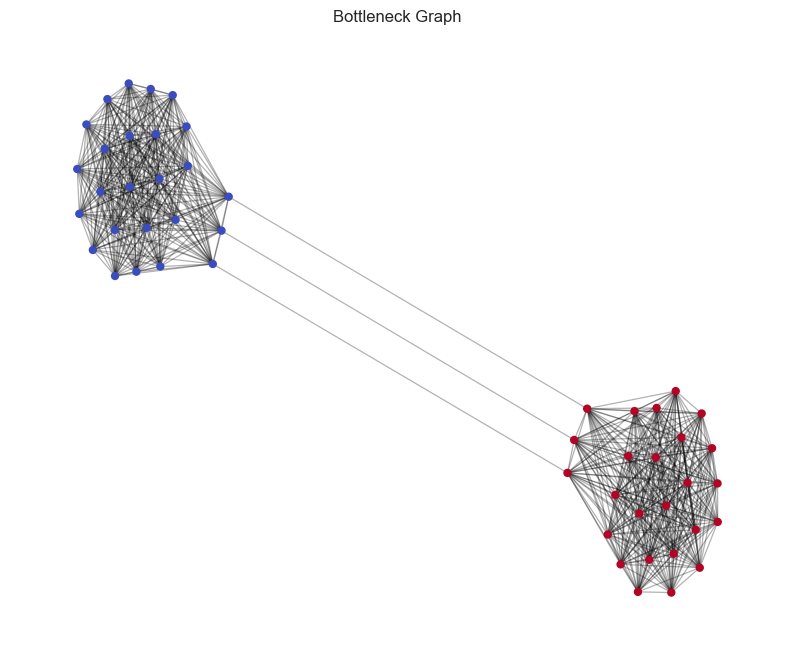

In [102]:
# plotting
G = to_networkx(
    data,
    to_undirected=True
)

pos = nx.spring_layout(G, seed=42)

# Separate bridge vs normal edges
bridge_edges = []
normal_edges = []

# Plot
fig, ax = plt.subplots(figsize=(10, 8))

nx.draw_networkx_nodes(
    G,
    pos,
    node_size=25,
    node_color=data.y.numpy(),
    cmap="coolwarm",
    ax=ax
)

nx.draw_networkx_edges(
    G,
    pos,
    alpha=.3,
    width=.9,
    ax=ax
)

ax.set_title("Bottleneck Graph")
ax.axis("off")

plt.show()

## 2. New Graphs w/ Bottlenecks

### 2.1 Laplacian Computation

In [103]:
# Section 2.1: run bottleneck experiments and index saved Laplacians.
working_directory = Path("/Users/luigifracassetti/projects/neural-sheaf-diffusion")
script_path = working_directory / "exp" / "scripts" / "run_bottleneck.sh"
venv_python = working_directory / ".venv" / "bin" / "python"
results_root = working_directory / "results" / "laplacians" / "bottleneck_exp"

# Keep this False by default so opening/running the notebook does not launch training accidentally.
BOTTLENECK_RUN_EXPERIMENTS = True
BOTTLENECK_NORMALISED_MODES = "false true"

# These are the three topology families supported by BottleneckData.
# Tune the numbers here, then run the generated bash command(s) below.
BOTTLENECK_EXPERIMENTS = [
    {
        "name": "barbell",
        "BOTTLENECK_GRAPH": "barbell",
        "BOTTLENECK_LEFT": 15,
        "BOTTLENECK_RIGHT": 15,
        "BRIDGE_WIDTH": 2,
        "BRIDGE_LENGTH": 0,
        "NUM_NODES": 160,
        "NUM_CLASSES": 2,
        "NUM_FEATS": 16,
        "BOTTLENECK_FEATURE_MODE": "ellipsoid",
    },
    {
        "name": "path_barbell",
        "BOTTLENECK_GRAPH": "path_barbell",
        "BOTTLENECK_LEFT": 15,
        "BOTTLENECK_RIGHT": 15,
        "BRIDGE_WIDTH": 3,
        "BRIDGE_LENGTH": 2,
        "NUM_NODES": 168,
        "NUM_CLASSES": 2,
        "NUM_FEATS": 16,
        "BOTTLENECK_FEATURE_MODE": "ellipsoid",
    },
    {
        "name": "sbm",
        "BOTTLENECK_GRAPH": "sbm",
        "BOTTLENECK_LEFT": 80,
        "BOTTLENECK_RIGHT": 80,
        "BRIDGE_WIDTH": 1,
        "BRIDGE_LENGTH": 0,
        "NUM_NODES": 60,
        "NUM_CLASSES": 3,
        "NUM_FEATS": 16,
        "BOTTLENECK_FEATURE_MODE": "ellipsoid",
        "SBM_INTRA_PROB": 0.5,
        "SBM_INTER_PROB": 0.002,
    },
]

BOTTLENECK_SHARED_ENV = {
    "PYTHON_EXEC": str(venv_python),
    "WANDB_MODE": "disabled",
    "ENTITY": os.environ.get("ENTITY", "local"),
    "BOTTLENECK_NORMALISED_MODES": BOTTLENECK_NORMALISED_MODES,
    "MODEL": "DiagSheaf",
    "LAYERS": 2,
    "EPOCHS": 500,
    "FOLDS": 3,
    "SEED": 43,
    "STALK_DIM": 1,
    "HIDDEN_CHANNELS": 16,
    "EARLY_STOPPING": 200,
    "LR": 0.01,
    "WEIGHT_DECAY": 0,
    "SHEAF_DECAY": 0,
    "FEAT_NOISE": 0.1,
    "ELLIPSOID_RADIUS": 1,
}


def shell_env(env):
    return " ".join(f"{key}={shlex.quote(str(value))}" for key, value in env.items())


def bottleneck_launch_commands(experiments=BOTTLENECK_EXPERIMENTS):
    rows = []
    for spec in experiments:
        env = {**BOTTLENECK_SHARED_ENV, **{k: v for k, v in spec.items() if k.isupper()}}
        command = f"cd {shlex.quote(str(working_directory))} && {shell_env(env)} sh {shlex.quote(str(script_path))}"
        rows.append({"experiment": spec["name"], "command": command, "script_exists": script_path.exists()})
    return pd.DataFrame(rows)


bottleneck_commands = bottleneck_launch_commands()
display(bottleneck_commands)

if BOTTLENECK_RUN_EXPERIMENTS:
    for command in bottleneck_commands["command"]:
        subprocess.run(["bash", "-lc", command], check=True)


def parse_bottleneck_laplacian_path(path):
    path = Path(path)
    pattern = re.compile(
        r"(?P<model>.+)_graph-(?P<graph>.+?)"
        r"_nodes-(?P<num_nodes>\d+)"
        r"_left-(?P<left>\d+)"
        r"_right-(?P<right>\d+)"
        r"_bridge-width-(?P<bridge_width>\d+)"
        r"_bridge-length-(?P<bridge_length>\d+)"
        r"_sbm-intra-(?P<sbm_intra_prob>[^_]+)"
        r"_sbm-inter-(?P<sbm_inter_prob>[^_]+)"
        r"_features-(?P<feature_mode>.+?)"
        r"_layer(?P<layer>\d+)"
        r"_classes-(?P<num_classes>\d+)"
        r"_feats-(?P<num_feats>\d+)"
        r"_fold(?P<fold>\d+)"
        r"_seed(?P<seed>\d+)\.pt$"
    )
    match = pattern.match(path.name)
    if not match:
        return None

    parts = path.parts
    value_from_suffix = lambda suffix: next((int(p[: -len(suffix)]) for p in parts if p.endswith(suffix) and p[: -len(suffix)].isdigit()), None)
    normalised = next((p.split("-", 1)[1] for p in parts if p.startswith("normalised-")), "legacy")
    stalk_dim = next((int(p.split("-", 1)[1]) for p in parts if p.startswith("stalk_dim-")), None)

    parsed = match.groupdict()
    parsed.update({
        "path": path,
        "normalised": normalised,
        "stalk_dim": stalk_dim,
        "layers": value_from_suffix("-layers"),
        "hidden": value_from_suffix("-hidden"),
        "epochs": value_from_suffix("-epochs"),
        "mtime": path.stat().st_mtime,
    })
    return parsed


def list_bottleneck_laplacians():
    rows = []
    for path in results_root.rglob("*.pt") if results_root.exists() else []:
        parsed = parse_bottleneck_laplacian_path(path)
        if parsed is not None:
            rows.append(parsed)
    index = pd.DataFrame(rows)
    if index.empty:
        return index

    int_cols = ["num_nodes", "left", "right", "bridge_width", "bridge_length", "layer", "num_classes", "num_feats", "fold", "seed", "stalk_dim", "layers", "hidden", "epochs"]
    float_cols = ["sbm_intra_prob", "sbm_inter_prob"]
    index[int_cols] = index[int_cols].apply(pd.to_numeric, errors="coerce")
    index[float_cols] = index[float_cols].apply(pd.to_numeric, errors="coerce")
    return index.sort_values(["graph", "feature_mode", "normalised", "layer", "fold", "mtime"])


bottleneck_laplacian_index = list_bottleneck_laplacians()
if bottleneck_laplacian_index.empty:
    print("No bottleneck_exp Laplacians found yet. Run one of the commands above, then rerun this cell.")
else:
    display(bottleneck_laplacian_index.drop(columns="mtime"))


,experiment,command,script_exists
0,barbell,cd /Users/luigifracassetti/projects/neural-she...,True
1,path_barbell,cd /Users/luigifracassetti/projects/neural-she...,True
2,sbm,cd /Users/luigifracassetti/projects/neural-she...,True


Processing...
Done!
  0%|          | 0/3 [00:00<?, ?it/s]

Running with wandb account: local
Namespace(epochs=500, lr=0.01, weight_decay=0.0, sheaf_decay=0.0, early_stopping=200, min_acc=0.0, stop_strategy='loss', d=1, layers=2, normalised=False, deg_normalised=False, linear=False, hidden_channels=16, input_dropout=0.0, dropout=0.0, left_weights=True, right_weights=True, add_lp=False, add_hp=False, use_act=True, second_linear=False, orth='householder', sheaf_act='tanh', edge_weights=False, sparse_learner=False, dataset='bottleneck_exp', seed=43, cuda=0, folds=3, model='DiagSheaf', entity='local', evectors=0, max_t=1.0, int_method=None, step_size=1, max_iters=100, adjoint_method='adaptive_heun', adjoint=False, adjoint_step_size=1, tol_scale=1.0, tol_scale_adjoint=1.0, max_nfe=1000, no_early=False, earlystopxT=3, max_test_steps=100, num_nodes=160, num_classes=2, num_feats=16, het_coef=0.9, edge_noise=0.05, node_degree=10, feat_noise=0.1, ellipsoid_radius=1.0, just_add_noise=False, ellipsoids=True, classes_corr=None, bottleneck_graph='barbell', b

 33%|███▎      | 1/3 [00:00<00:01,  1.91it/s]

Fold 1 | Epochs: 200 | Best epoch: 0
Test acc: 0.3333
Best val acc: 0.3333
Laplacian 0: Max: 0.1481, Min: -0.3453, Avg: -0.2264, Abs avg: 0.2323
Laplacian 1: Max: 0.9998, Min: -0.9729, Avg: 0.4493, Abs avg: 0.5859
Epsilons 0: [0.23]
Epsilons 1: [0.208]
Saved Laplacian to /Users/luigifracassetti/projects/neural-sheaf-diffusion/results/laplacians/bottleneck_exp/normalised-false/stalk_dim-1/2-layers/16-hidden/500-epochs/DiagSheaf_graph-barbell_nodes-160_left-15_right-15_bridge-width-2_bridge-length-0_sbm-intra-0.25_sbm-inter-0.005_features-ellipsoid_layer0_classes-2_feats-16_fold1_seed43.pt with shape (3, 454)
Saved Laplacian to /Users/luigifracassetti/projects/neural-sheaf-diffusion/results/laplacians/bottleneck_exp/normalised-false/stalk_dim-1/2-layers/16-hidden/500-epochs/DiagSheaf_graph-barbell_nodes-160_left-15_right-15_bridge-width-2_bridge-length-0_sbm-intra-0.25_sbm-inter-0.005_features-ellipsoid_layer1_classes-2_feats-16_fold1_seed43.pt with shape (3, 454)


...

Fold 1 | Epochs: 217 | Best epoch: 17
Test acc: 0.2500
Best val acc: 0.4167
Laplacian 0: Max: 0.3212, Min: -0.6296, Avg: -0.0817, Abs avg: 0.1098
Laplacian 1: Max: 0.9696, Min: -0.7168, Avg: 0.1018, Abs avg: 0.2950
Epsilons 0: [0.437]
Epsilons 1: [0.455]
Saved Laplacian to /Users/luigifracassetti/projects/neural-sheaf-diffusion/results/laplacians/bottleneck_exp/normalised-true/stalk_dim-1/2-layers/16-hidden/500-epochs/DiagSheaf_graph-sbm_nodes-60_left-80_right-80_bridge-width-1_bridge-length-0_sbm-intra-0.5_sbm-inter-0.002_features-ellipsoid_layer0_classes-3_feats-16_fold1_seed43.pt with shape (3, 614)
Saved Laplacian to /Users/luigifracassetti/projects/neural-sheaf-diffusion/results/laplacians/bottleneck_exp/normalised-true/stalk_dim-1/2-layers/16-hidden/500-epochs/DiagSheaf_graph-sbm_nodes-60_left-80_right-80_bridge-width-1_bridge-length-0_sbm-intra-0.5_sbm-inter-0.002_features-ellipsoid_layer1_classes-3_feats-16_fold1_seed43.pt with shape (3, 614)


 67%|██████▋   | 2/3 [00:00<00:00,  2.55it/s]

Fold 2 | Epochs: 216 | Best epoch: 16
Test acc: 0.4167
Best val acc: 0.4167
Laplacian 0: Max: 0.9149, Min: -0.2696, Avg: 0.0871, Abs avg: 0.1797
Laplacian 1: Max: 0.9971, Min: -0.6711, Avg: 0.1111, Abs avg: 0.4433
Epsilons 0: [0.48]
Epsilons 1: [0.479]
Saved Laplacian to /Users/luigifracassetti/projects/neural-sheaf-diffusion/results/laplacians/bottleneck_exp/normalised-true/stalk_dim-1/2-layers/16-hidden/500-epochs/DiagSheaf_graph-sbm_nodes-60_left-80_right-80_bridge-width-1_bridge-length-0_sbm-intra-0.5_sbm-inter-0.002_features-ellipsoid_layer0_classes-3_feats-16_fold2_seed43.pt with shape (3, 614)
Saved Laplacian to /Users/luigifracassetti/projects/neural-sheaf-diffusion/results/laplacians/bottleneck_exp/normalised-true/stalk_dim-1/2-layers/16-hidden/500-epochs/DiagSheaf_graph-sbm_nodes-60_left-80_right-80_bridge-width-1_bridge-length-0_sbm-intra-0.5_sbm-inter-0.002_features-ellipsoid_layer1_classes-3_feats-16_fold2_seed43.pt with shape (3, 614)
DiagSheaf on bottleneck_exp | SHA: 5d

100%|██████████| 3/3 [00:01<00:00,  2.60it/s]


,model,graph,num_nodes,left,right,bridge_width,bridge_length,sbm_intra_prob,sbm_inter_prob,feature_mode,...,num_classes,num_feats,fold,seed,path,normalised,stalk_dim,layers,hidden,epochs
84,DiagSheaf,barbell,160,80,80,1,0,0.25,0.0050,ellipsoid,...,2,8,0,43,/Users/luigifracassetti/projects/neural-sheaf-...,false,1,2,16,500
130,DiagSheaf,barbell,160,20,20,2,0,0.25,0.0050,ellipsoid,...,2,16,0,43,/Users/luigifracassetti/projects/neural-sheaf-...,false,1,2,16,500
140,DiagSheaf,barbell,160,10,10,1,0,0.25,0.0050,ellipsoid,...,2,16,0,43,/Users/luigifracassetti/projects/neural-sheaf-...,false,1,2,16,500
99,DiagSheaf,barbell,160,100,100,3,0,0.25,0.0050,ellipsoid,...,2,16,0,43,/Users/luigifracassetti/projects/neural-sheaf-...,false,1,2,16,500
78,DiagSheaf,barbell,160,15,15,2,0,0.25,0.0050,ellipsoid,...,2,16,0,43,/Users/luigifracassetti/projects/neural-sheaf-...,false,1,2,16,500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41,DiagSheaf,sbm,160,80,80,1,0,0.50,0.0025,random,...,4,16,1,43,/Users/luigifracassetti/projects/neural-sheaf-...,true,1,2,16,500
23,DiagSheaf,sbm,160,80,80,1,0,0.50,0.0025,random,...,4,16,2,43,/Users/luigifracassetti/projects/neural-sheaf-...,true,1,2,16,500
45,DiagSheaf,sbm,160,80,80,1,0,0.50,0.0025,random,...,4,16,0,43,/Users/luigifracassetti/projects/neural-sheaf-...,true,1,2,16,500
62,DiagSheaf,sbm,160,80,80,1,0,0.50,0.0025,random,...,4,16,1,43,/Users/luigifracassetti/projects/neural-sheaf-...,true,1,2,16,500


### 2.2 Ollivier-Ricci Curvature

In [104]:
# Section 2.2 helpers: GraphRicciCurvature wrapper and visual diagnostics.
GRAPH_RICCI_ALPHA = 0.999
GRAPH_RICCI_METHOD = "OTD"
GRAPH_RICCI_WEIGHT = "weight"
GRAPH_RICCI_PROC = 1
GRAPH_RICCI_SHORTEST_PATH = "all_pairs"
GRAPH_RICCI_VERBOSE = "ERROR"
GRAPH_RICCI_TANH_SCALE = True
GRAPH_RICCI_LIMIT_CURV = True
GRAPH_RICCI_OTD_NODE_LIMIT = 1e6
GRAPH_RICCI_OTD_EDGE_LIMIT = 1e6
GRAPH_RICCI_LAYOUT_EDGE_LIMIT = 1e6
WEIGHT_SCATTER_NORMALIZATION = None # None, zscore, minmax, log1p
SEED = BOTTLENECK_SHARED_ENV["SEED"]


def clean_graph(G):
    H = nx.convert_node_labels_to_integers(G)
    H = nx.Graph(H)
    H.remove_edges_from(nx.selfloop_edges(H))
    return H


def prepare_graph_for_graph_ricci(G, weight=GRAPH_RICCI_WEIGHT, default_weight=1.0):
    H = clean_graph(G)
    for _, _, data in H.edges(data=True):
        edge_weight = data.get(weight, default_weight)
        try:
            edge_weight = float(edge_weight)
        except (TypeError, ValueError):
            edge_weight = default_weight
        if not np.isfinite(edge_weight) or edge_weight <= 0:
            edge_weight = default_weight
        data[weight] = edge_weight
    return H


def edge_curvature_dict(G, curvature_attribute="ricciCurvature"):
    return {
        tuple(sorted((u, v))): float(data[curvature_attribute])
        for u, v, data in G.edges(data=True)
        if curvature_attribute in data
    }


def summarize_edge_curvature(values):
    values = np.array(values, dtype=float)
    if len(values) == 0:
        return {"min": np.nan, "mean": np.nan, "median": np.nan, "max": np.nan, "std": np.nan}
    return {
        "min": float(values.min()),
        "mean": float(values.mean()),
        "median": float(np.median(values)),
        "max": float(values.max()),
        "std": float(values.std()),
    }


def choose_graph_ricci_method(graph, requested_method=GRAPH_RICCI_METHOD):
    """Avoid exact OTD on dense bottleneck graphs, which can crash notebook kernels."""
    if requested_method == "OTD" and (
        graph.number_of_nodes() > GRAPH_RICCI_OTD_NODE_LIMIT
        or graph.number_of_edges() > GRAPH_RICCI_OTD_EDGE_LIMIT
    ):
        return "OTDSinkhornMix"
    return requested_method


def compute_graph_ollivier_ricci(
    G,
    alpha=GRAPH_RICCI_ALPHA,
    method=GRAPH_RICCI_METHOD,
    weight=GRAPH_RICCI_WEIGHT,
    proc=GRAPH_RICCI_PROC,
    shortest_path=GRAPH_RICCI_SHORTEST_PATH,
    verbose=GRAPH_RICCI_VERBOSE,
    limit_curv=GRAPH_RICCI_LIMIT_CURV,
):
    H = prepare_graph_for_graph_ricci(G, weight=weight)
    # method = choose_graph_ricci_method(H, method)
    if H.number_of_edges() == 0:
        edge_rc = {}
        summary = summarize_edge_curvature([])
    else:
        from GraphRicciCurvature.OllivierRicci import OllivierRicci

        orc = OllivierRicci(
            G=H,
            weight=weight,
            alpha=alpha,
            method=method,
            proc=proc,
            shortest_path=shortest_path,
            verbose=verbose,
        )
        H = orc.compute_ricci_curvature()
        edge_rc = edge_curvature_dict(H)
        if limit_curv:
            edge_rc = {edge: value / (1 - alpha) for edge, value in edge_rc.items()}
        summary = summarize_edge_curvature(list(edge_rc.values()))

    summary.update({
        "nodes": H.number_of_nodes(),
        "edges": H.number_of_edges(),
        "components": nx.number_connected_components(H),
        "alpha": alpha,
        "method": method,
    })
    return {"graph": H, "edge_curvature": edge_rc, "summary": summary}


def edge_weights_from_laplacian_path(path, num_nodes, stalk_dim=1, reducer="mean"):
    laplacian = torch.load(path, weights_only=False).detach().cpu()
    rows = laplacian[0].long().numpy()
    cols = laplacian[1].long().numpy()
    values = laplacian[2].abs().numpy()
    stalk_dim = int(stalk_dim or max(1, int(np.ceil((max(rows.max(), cols.max()) + 1) / num_nodes))))

    buckets = {}
    for row, col, value in zip(rows, cols, values):
        u, v = int(row // stalk_dim), int(col // stalk_dim)
        if u == v or u >= num_nodes or v >= num_nodes:
            continue
        edge = tuple(sorted((u, v)))
        buckets.setdefault(edge, []).append(float(value))

    if reducer == "max":
        return {edge: max(vals) for edge, vals in buckets.items()}
    return {edge: float(np.mean(vals)) for edge, vals in buckets.items()}


def build_weighted_graph_from_laplacian_edges(edge_weights_dict, num_nodes=None, min_distance=1e-12):
    graph = nx.Graph()
    if num_nodes is not None:
        graph.add_nodes_from(range(int(num_nodes)))
    elif edge_weights_dict:
        graph.add_nodes_from(range(max(max(edge) for edge in edge_weights_dict) + 1))
    for (u, v), value in edge_weights_dict.items():
        distance = max(abs(float(value)), min_distance)
        graph.add_edge(int(u), int(v), weight=distance, laplacian_weight=distance)
    return graph


def materialise_bottleneck_data(row):
    import sys as _sys
    from pathlib import Path as _Path

    project_root = globals().get("working_directory", _Path("/Users/luigifracassetti/projects/neural-sheaf-diffusion"))
    project_root_string = str(project_root)
    if project_root_string not in _sys.path:
        _sys.path.insert(0, project_root_string)

    from utils.heterophilic import BottleneckData

    args = SimpleNamespace(
        bottleneck_graph=row["graph"],
        num_nodes=int(row["num_nodes"]),
        num_classes=int(row["num_classes"]),
        num_feats=int(row["num_feats"]),
        bottleneck_left=int(row["left"]),
        bottleneck_right=int(row["right"]),
        bridge_width=int(row["bridge_width"]),
        bridge_length=int(row["bridge_length"]),
        sbm_intra_prob=float(row["sbm_intra_prob"]),
        sbm_inter_prob=float(row["sbm_inter_prob"]),
        bottleneck_feature_mode=row["feature_mode"],
        ellipsoid_radius=BOTTLENECK_SHARED_ENV["ELLIPSOID_RADIUS"],
        feat_noise=BOTTLENECK_SHARED_ENV["FEAT_NOISE"],
        seed=int(row["seed"]),
    )
    with TemporaryDirectory(dir="/private/tmp") as root:
        dataset = BottleneckData(root, "bottleneck_exp", args)
        return dataset[0]


def undirected_edges_from_data(data):
    edge_index = data.edge_index.detach().cpu().numpy()
    edges = {tuple(sorted((int(u), int(v)))) for u, v in edge_index.T if int(u) != int(v)}
    return np.array(sorted(edges), dtype=int)


def analyse_bottleneck_dataset(data):
    x = data.x.detach().cpu().numpy()
    y = data.y.detach().cpu().numpy().astype(int)
    edges = undirected_edges_from_data(data)
    degree = np.bincount(edges.ravel(), minlength=x.shape[0]) if len(edges) else np.zeros(x.shape[0], dtype=int)

    x_centered = x - x.mean(axis=0, keepdims=True)
    if min(x_centered.shape) >= 2:
        _, _, vt = np.linalg.svd(x_centered, full_matrices=False)
        pc = x_centered @ vt[:2].T
    else:
        pc = np.zeros((x.shape[0], 2))

    node_df = pd.DataFrame({
        "node": np.arange(x.shape[0]),
        "class": y,
        "degree": degree,
        "feature_norm": np.linalg.norm(x, axis=1),
        "pc1": pc[:, 0],
        "pc2": pc[:, 1],
    })
    same_class = np.array([y[u] == y[v] for u, v in edges], dtype=bool) if len(edges) else np.array([], dtype=bool)
    overview = pd.DataFrame([{
        "nodes": x.shape[0],
        "features": x.shape[1],
        "classes": int(np.unique(y).size),
        "undirected_edges": int(len(edges)),
        "mean_degree": float(degree.mean()),
        "edge_homophily": float(same_class.mean()) if len(same_class) else np.nan,
    }])
    return overview, node_df


def edge_plot_values(graph, curvature_dict):
    rows = [
        (edge, graph[u][v]["laplacian_weight"], curvature_dict.get(tuple(sorted(edge)), np.nan))
        for edge in graph.edges()
        for u, v in [edge]
    ]
    rows = [(edge, weight, curvature) for edge, weight, curvature in rows if np.isfinite(curvature)]
    if not rows:
        return [], np.array([]), np.array([])
    edges, weights, curvatures = zip(*rows)
    return list(edges), np.array(weights), np.array(curvatures)


def normalise_values(values, mode=None):
    values = np.asarray(values, dtype=float)
    if mode is None:
        return values, "|L_ij|"
    if mode == "minmax":
        span = values.max() - values.min()
        return (values - values.min()) / span if span > 0 else values * 0, "min-max |L_ij|"
    if mode == "zscore":
        std = values.std()
        return (values - values.mean()) / std if std > 0 else values * 0, "z-score |L_ij|"
    if mode == "log1p":
        return np.log1p(values), "log(1 + |L_ij|)"
    raise ValueError("Unsupported WEIGHT_SCATTER_NORMALIZATION.")


def linear_fit_metrics(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    valid = np.isfinite(x) & np.isfinite(y)
    if valid.sum() < 2:
        return np.nan, np.nan, np.nan, np.nan
    x, y = x[valid], y[valid]
    slope, intercept = np.polyfit(x, y, deg=1)
    y_hat = slope * x + intercept
    ss_res = np.sum((y - y_hat) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
    pearson_r = np.corrcoef(x, y)[0, 1] if np.std(x) > 0 and np.std(y) > 0 else np.nan
    return float(slope), float(intercept), float(r2), float(pearson_r)


def add_metric_fit(ax, x, y, color="#111827"):
    slope, intercept, r2, pearson_r = linear_fit_metrics(x, y)
    if not np.isfinite(slope):
        return r2, pearson_r
    x = np.asarray(x, dtype=float)
    valid = np.isfinite(x) & np.isfinite(y)
    x_line = np.linspace(x[valid].min(), x[valid].max(), 100)
    ax.plot(x_line, slope * x_line + intercept, color=color, linewidth=2)
    ax.text(
        0.02, 0.98, f"R^2 = {r2:.3f}\nr = {pearson_r:.3f}",
        transform=ax.transAxes, ha="left", va="top",
        bbox={"boxstyle": "round,pad=0.3", "facecolor": "white", "edgecolor": "#cbd5e1", "alpha": 0.9},
    )
    return r2, pearson_r


def draw_basic_edge_graph(graph, positions, edges, values, ax, title, cmap, label, vmin=None, vmax=None, node_size=8):
    nx.draw_networkx_nodes(graph, positions, node_size=node_size, node_color="black", ax=ax, alpha=0.4)
    edge_collection = nx.draw_networkx_edges(
        graph, positions, edgelist=edges, edge_color=values, edge_cmap=cmap,
        edge_vmin=vmin, edge_vmax=vmax, width=1.6, ax=ax,
    )
    ax.set_title(title)
    ax.axis("off")
    plt.colorbar(edge_collection, ax=ax, fraction=0.046, pad=0.02, label=label)


def draw_node_class_graph(graph, node_df, positions, ax, node_size=20):
    node_classes = node_df.set_index("node").reindex(list(graph.nodes()))["class"].to_numpy()
    nx.draw_networkx_edges(graph, positions, edge_color="#cbd5e1", width=.8, alpha=0.6, ax=ax)
    nodes = nx.draw_networkx_nodes(
        graph, positions, node_color=node_classes, cmap=plt.cm.tab10,
        node_size=node_size, edgecolors="#0f172a", linewidths=0.2, ax=ax,
    )
    ax.set_title("Classes on nodes")
    ax.axis("off")
    plt.colorbar(nodes, ax=ax, fraction=0.046, pad=0.02, label="class")


def display_edges_for_layout(edges, values, limit=GRAPH_RICCI_LAYOUT_EDGE_LIMIT):
    """Keep dense clique drawings readable while histograms/scatters still use all edges."""
    if len(edges) <= limit:
        return edges, values
    rng = np.random.default_rng(SEED)
    chosen = np.sort(rng.choice(len(edges), size=limit, replace=False))
    return [edges[i] for i in chosen], values[chosen]


def plot_basic_bottleneck_dataset_views(data, node_df, curvature_result, title, bins=25):
    graph = curvature_result["graph"]
    edges, weights, curvatures = edge_plot_values(graph, curvature_result["edge_curvature"])
    shown_curvatures = np.tanh(curvatures) if GRAPH_RICCI_TANH_SCALE else curvatures
    curvature_label = "tanh(OR curvature)" if GRAPH_RICCI_TANH_SCALE else "OR curvature"
    scatter_weights, scatter_weight_label = normalise_values(weights, WEIGHT_SCATTER_NORMALIZATION)
    layout_weight_edges, layout_weights = display_edges_for_layout(edges, weights)
    layout_curvature_edges, layout_curvatures = display_edges_for_layout(edges, shown_curvatures)

    fig, ax = plt.subplot_mosaic(
        [["weights_graph", "curvature_graph", "classes"], ["weight_hist", "curvature_hist", "correlation"]],
        figsize=(18, 9), constrained_layout=True,
    )
    positions = nx.spring_layout(graph, seed=SEED, weight=None, iterations=30)

    draw_basic_edge_graph(graph, positions, layout_weight_edges, layout_weights, ax["weights_graph"], "Weights on edges", plt.cm.viridis, "|L_ij|")
    draw_basic_edge_graph(
        graph, positions, layout_curvature_edges, layout_curvatures, ax["curvature_graph"], "Curvature on edges",
        plt.cm.coolwarm, curvature_label, -1 if GRAPH_RICCI_TANH_SCALE else None, 1 if GRAPH_RICCI_TANH_SCALE else None,
    )
    draw_node_class_graph(graph, node_df, positions, ax["classes"])

    sns.histplot(weights, bins=bins, kde=True, color="#2563eb", ax=ax["weight_hist"])
    sns.histplot(shown_curvatures, bins=bins, kde=True, color="#dc2626", ax=ax["curvature_hist"])
    sns.scatterplot(x=scatter_weights, y=shown_curvatures, s=35, color="#059669", edgecolor="white", ax=ax["correlation"])
    _, pearson_r = add_metric_fit(ax["correlation"], scatter_weights, shown_curvatures)

    ax["weight_hist"].set(title="Weight distribution", xlabel="|L_ij|", ylabel="edge count")
    ax["curvature_hist"].axvline(0, color="#0f172a", linestyle="--", linewidth=1)
    ax["curvature_hist"].set(title="Curvature distribution", xlabel=curvature_label, ylabel="edge count")
    ax["correlation"].axhline(0, color="#0f172a", linestyle="--", linewidth=1)
    ax["correlation"].set(title=f"Weights vs curvature (r={pearson_r:.3f})", xlabel=scatter_weight_label, ylabel=curvature_label)
    fig.suptitle(title, fontsize=14)
    plt.show()


def build_feature_edge_frame(data, curvature_result):
    x = data.x.detach().cpu().numpy()
    y = data.y.detach().cpu().numpy().astype(int)
    edges, weights, curvatures = edge_plot_values(curvature_result["graph"], curvature_result["edge_curvature"])
    shown_curvatures = np.tanh(curvatures) if GRAPH_RICCI_TANH_SCALE else curvatures
    rows = []
    for (u, v), weight, curvature, shown_curvature in zip(edges, weights, curvatures, shown_curvatures):
        if max(u, v) >= len(y):
            continue
        source_class, target_class = int(y[u]), int(y[v])
        source_norm = float(np.linalg.norm(x[u]))
        target_norm = float(np.linalg.norm(x[v]))
        denom = source_norm * target_norm
        rows.append({
            "source": int(u), "target": int(v),
            "source_class": source_class, "target_class": target_class,
            "class_pair": "-".join(map(str, sorted((source_class, target_class)))),
            "same_class": source_class == target_class,
            "source_feature_norm": source_norm,
            "target_feature_norm": target_norm,
            "feature_norm_diff": abs(source_norm - target_norm),
            "feature_distance": float(np.linalg.norm(x[u] - x[v])),
            "feature_cosine": float(np.dot(x[u], x[v]) / denom) if denom > 0 else np.nan,
            "weight": float(weight),
            "curvature": float(curvature),
            "shown_curvature": float(shown_curvature),
        })
    return pd.DataFrame(rows)


,model,graph,num_nodes,left,right,bridge_width,bridge_length,sbm_intra_prob,sbm_inter_prob,feature_mode,...,num_classes,num_feats,fold,seed,path,normalised,stalk_dim,layers,hidden,epochs
124,DiagSheaf,sbm,60,80,80,1,0,0.5,0.002,ellipsoid,...,3,16,0,43,/Users/luigifracassetti/projects/neural-sheaf-...,false,1,2,16,500
50,DiagSheaf,sbm,60,80,80,1,0,0.5,0.002,ellipsoid,...,3,16,0,43,/Users/luigifracassetti/projects/neural-sheaf-...,true,1,2,16,500


Computing OR for graph=sbm, normalised=false, nodes=60, edges=277, method=OTD


Processing...
Done!


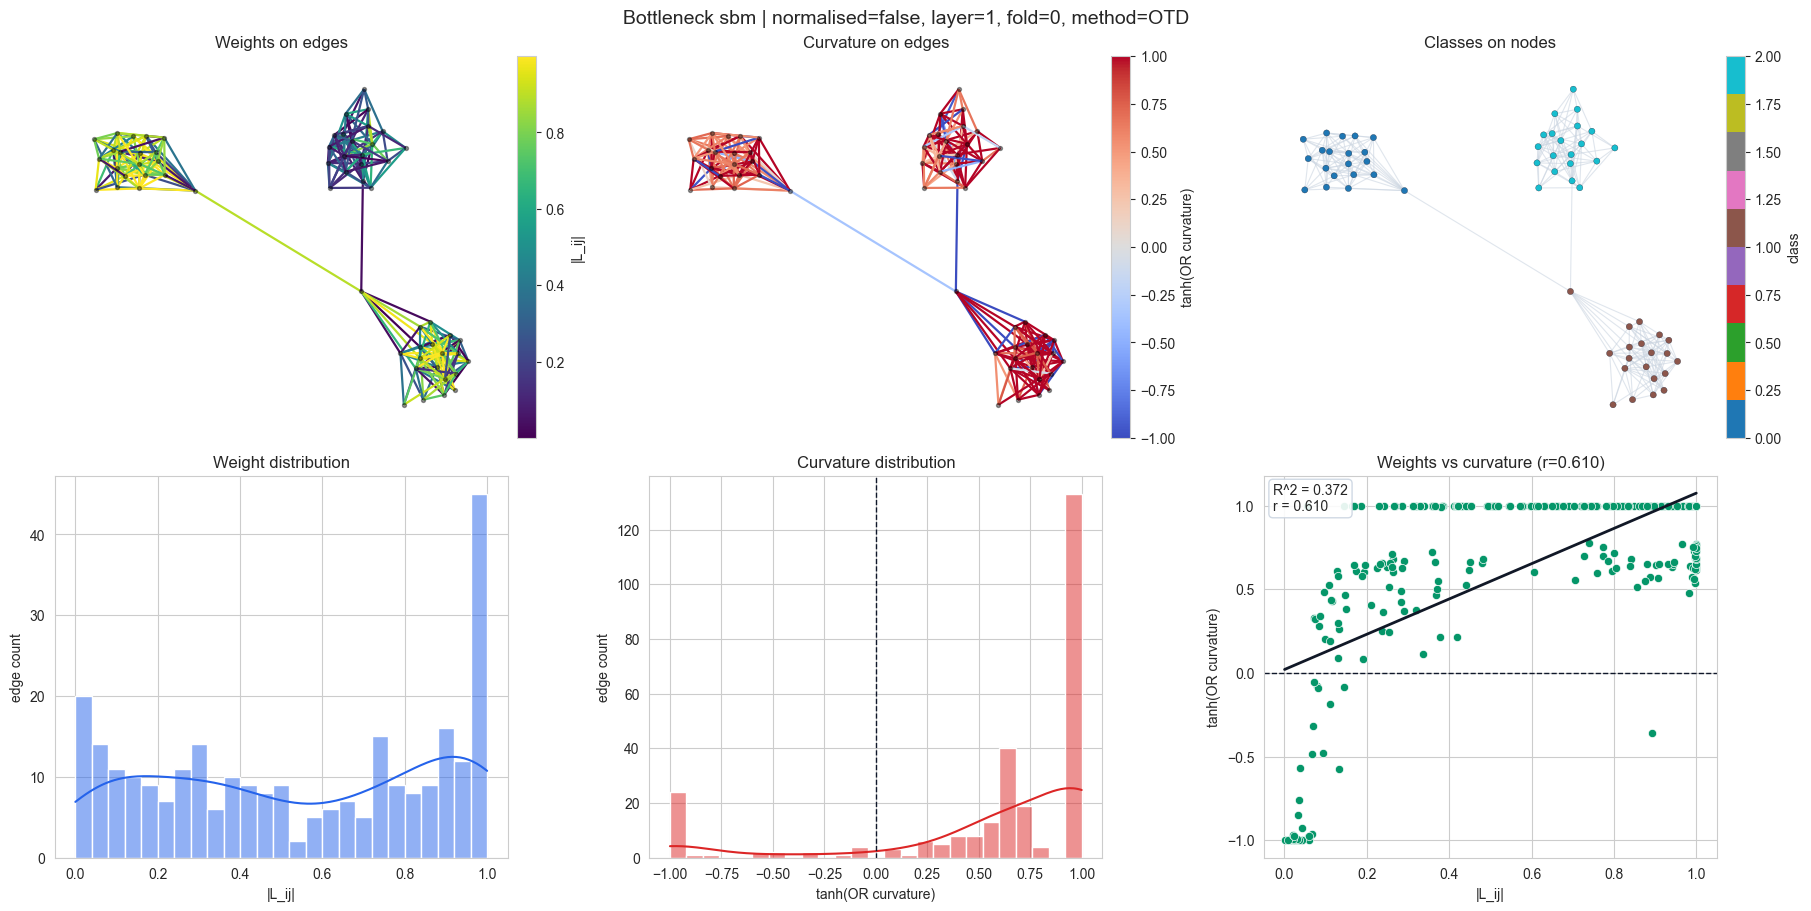

,graph,normalised,layer,fold,source,target,source_class,target_class,class_pair,same_class,source_feature_norm,target_feature_norm,feature_norm_diff,feature_distance,feature_cosine,weight,curvature,shown_curvature
0,sbm,false,1,0,0,2,0,0,0-0,True,0.548836,0.738220,0.189385,0.858520,0.134679,0.377686,0.216746,0.213414
1,sbm,false,1,0,0,3,0,0,0-0,True,0.548836,0.597802,0.048966,0.765919,0.109657,0.990442,0.654213,0.574499
2,sbm,false,1,0,0,6,0,0,0-0,True,0.548836,0.516578,0.032258,0.805984,-0.143797,0.999604,0.719242,0.616439
3,sbm,false,1,0,0,8,0,0,0-0,True,0.548836,0.623104,0.074268,0.946807,-0.302597,0.981798,0.521246,0.478661
4,sbm,false,1,0,0,9,0,0,0-0,True,0.548836,0.635502,0.086667,0.801058,0.090872,0.384041,116.990171,1.000000
5,sbm,false,1,0,0,10,0,0,0-0,True,0.548836,0.697803,0.148967,0.973350,-0.207923,0.190753,0.085167,0.084962
6,sbm,false,1,0,0,13,0,0,0-0,True,0.548836,0.447297,0.101539,0.584068,0.326201,0.237245,0.253538,0.248241
7,sbm,false,1,0,0,14,0,0,0-0,True,0.548836,0.595865,0.047029,0.722402,0.205501,0.057327,-2.352185,-0.982051
8,sbm,false,1,0,0,15,0,0,0-0,True,0.548836,0.641685,0.092849,0.852595,-0.019787,0.918391,159.890453,1.000000
9,sbm,false,1,0,0,16,0,0,0-0,True,0.548836,0.630763,0.081927,0.655473,0.389153,0.383553,90.887971,1.000000


Computing OR for graph=sbm, normalised=true, nodes=60, edges=277, method=OTD


Processing...
Done!


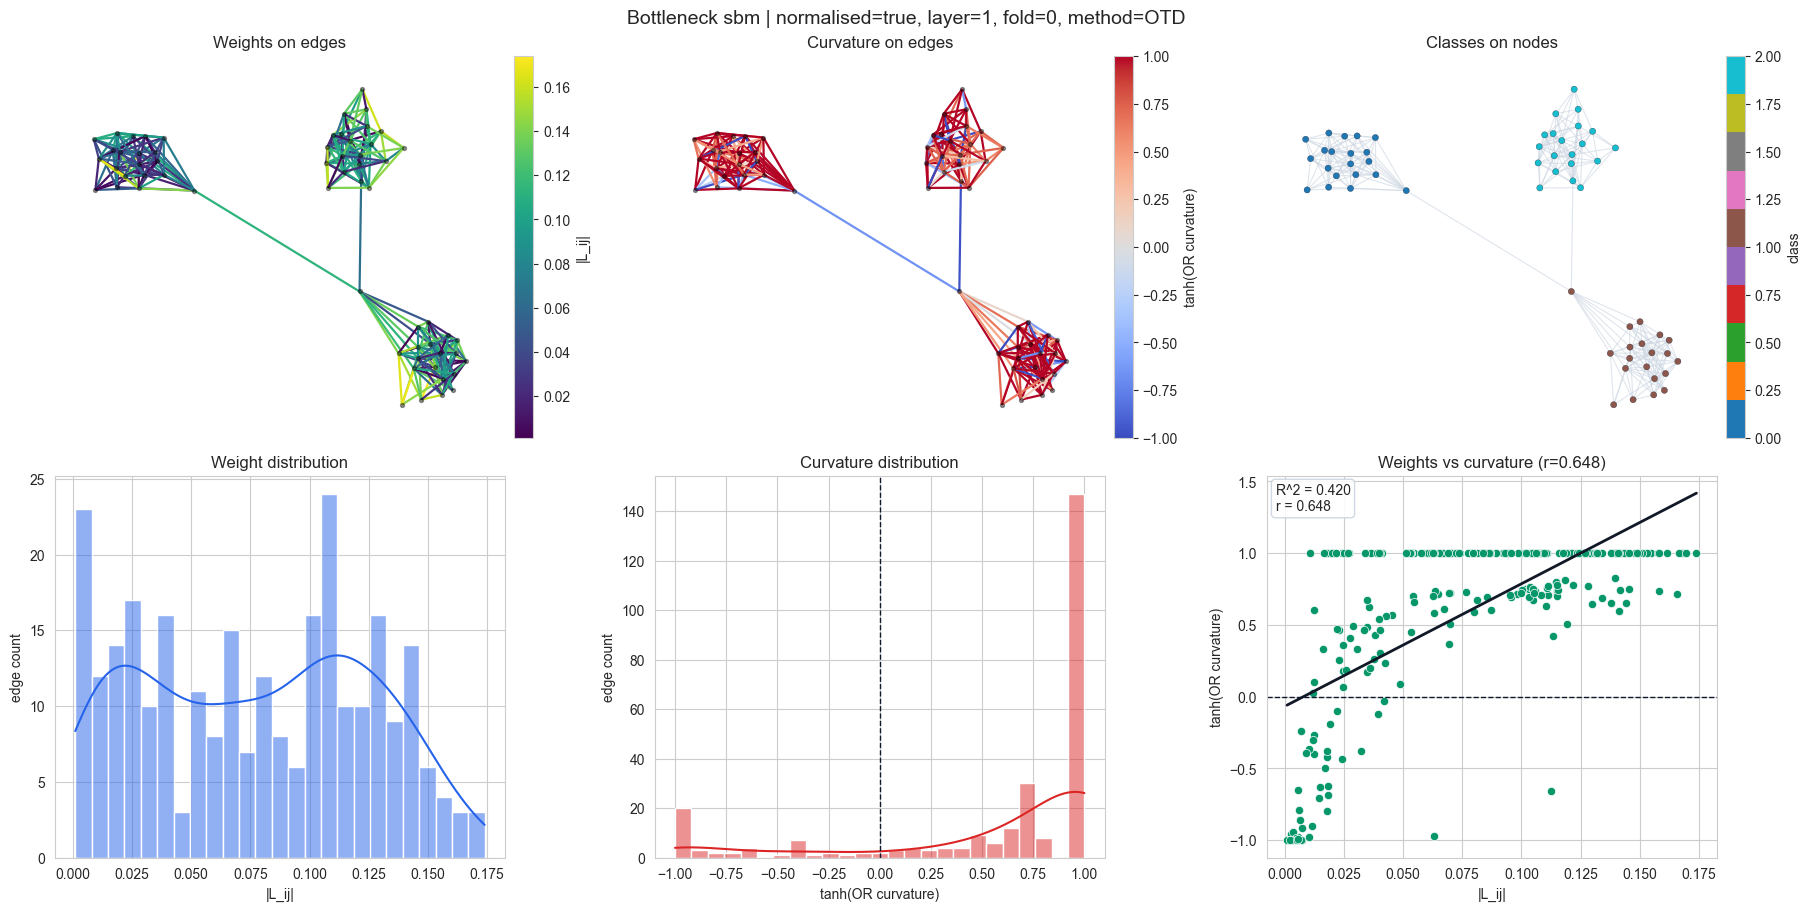

,graph,normalised,layer,fold,source,target,source_class,target_class,class_pair,same_class,source_feature_norm,target_feature_norm,feature_norm_diff,feature_distance,feature_cosine,weight,curvature,shown_curvature
0,sbm,true,1,0,0,2,0,0,0-0,True,0.548836,0.738220,0.189385,0.858520,0.134679,0.032482,-0.396867,-0.377265
1,sbm,true,1,0,0,3,0,0,0-0,True,0.548836,0.597802,0.048966,0.765919,0.109657,0.107558,817.944906,1.000000
2,sbm,true,1,0,0,6,0,0,0-0,True,0.548836,0.516578,0.032258,0.805984,-0.143797,0.142298,894.539386,1.000000
3,sbm,true,1,0,0,8,0,0,0-0,True,0.548836,0.623104,0.074268,0.946807,-0.302597,0.110964,629.449531,1.000000
4,sbm,true,1,0,0,9,0,0,0-0,True,0.548836,0.635502,0.086667,0.801058,0.090872,0.054490,626.237666,1.000000
5,sbm,true,1,0,0,10,0,0,0-0,True,0.548836,0.697803,0.148967,0.973350,-0.207923,0.084717,742.762634,1.000000
6,sbm,true,1,0,0,13,0,0,0-0,True,0.548836,0.447297,0.101539,0.584068,0.326201,0.016992,-0.543151,-0.495370
7,sbm,true,1,0,0,14,0,0,0-0,True,0.548836,0.595865,0.047029,0.722402,0.205501,0.027014,332.049465,1.000000
8,sbm,true,1,0,0,15,0,0,0-0,True,0.548836,0.641685,0.092849,0.852595,-0.019787,0.012249,-0.422797,-0.399284
9,sbm,true,1,0,0,16,0,0,0-0,True,0.548836,0.630763,0.081927,0.655473,0.389153,0.073147,279.556054,1.000000


,nodes,features,classes,undirected_edges,mean_degree,edge_homophily,min,mean,median,max,std,edges,components,alpha,method,graph,normalised,layer,fold,laplacian_path
0,60,16.0,3.0,277.0,9.233333,0.99278,-355.884619,222.748308,0.975749,926.025071,309.520406,277,1,0.999,OTD,sbm,false,1,0,/Users/luigifracassetti/projects/neural-sheaf-...
1,60,16.0,3.0,277.0,9.233333,0.99278,-17.025846,204.645229,36.798386,933.818323,261.271622,277,1,0.999,OTD,sbm,true,1,0,/Users/luigifracassetti/projects/neural-sheaf-...


,graph,normalised,layer,fold,source,target,source_class,target_class,class_pair,same_class,source_feature_norm,target_feature_norm,feature_norm_diff,feature_distance,feature_cosine,weight,curvature,shown_curvature
0,sbm,false,1,0,0,2,0,0,0-0,True,0.548836,0.738220,0.189385,0.858520,0.134679,0.377686,0.216746,0.213414
1,sbm,false,1,0,0,3,0,0,0-0,True,0.548836,0.597802,0.048966,0.765919,0.109657,0.990442,0.654213,0.574499
2,sbm,false,1,0,0,6,0,0,0-0,True,0.548836,0.516578,0.032258,0.805984,-0.143797,0.999604,0.719242,0.616439
3,sbm,false,1,0,0,8,0,0,0-0,True,0.548836,0.623104,0.074268,0.946807,-0.302597,0.981798,0.521246,0.478661
4,sbm,false,1,0,0,9,0,0,0-0,True,0.548836,0.635502,0.086667,0.801058,0.090872,0.384041,116.990171,1.000000
5,sbm,false,1,0,0,10,0,0,0-0,True,0.548836,0.697803,0.148967,0.973350,-0.207923,0.190753,0.085167,0.084962
6,sbm,false,1,0,0,13,0,0,0-0,True,0.548836,0.447297,0.101539,0.584068,0.326201,0.237245,0.253538,0.248241
7,sbm,false,1,0,0,14,0,0,0-0,True,0.548836,0.595865,0.047029,0.722402,0.205501,0.057327,-2.352185,-0.982051
8,sbm,false,1,0,0,15,0,0,0-0,True,0.548836,0.641685,0.092849,0.852595,-0.019787,0.918391,159.890453,1.000000
9,sbm,false,1,0,0,16,0,0,0-0,True,0.548836,0.630763,0.081927,0.655473,0.389153,0.383553,90.887971,1.000000


In [109]:
# Compute Ollivier-Ricci curvature for matching normalised/unnormalised Laplacians.
if bottleneck_laplacian_index.empty:
    raise RuntimeError("No bottleneck Laplacians are indexed. Run Section 2.1 experiments first.")

# Select one topology here. Available values usually include: barbell, path_barbell, sbm.
SELECTED_BOTTLENECK_GRAPH = "sbm"
SELECTED_LAYER = 1
SELECTED_FOLD = 0

selected_index = bottleneck_laplacian_index[
    (bottleneck_laplacian_index["graph"] == SELECTED_BOTTLENECK_GRAPH)
    & (bottleneck_laplacian_index["layer"] == SELECTED_LAYER)
    & (bottleneck_laplacian_index["fold"] == SELECTED_FOLD)
].copy()

if selected_index.empty:
    raise FileNotFoundError(
        f"No Laplacian found for graph={SELECTED_BOTTLENECK_GRAPH}, layer={SELECTED_LAYER}, fold={SELECTED_FOLD}."
    )

# Prefer the most recent pair for each normalisation mode.
selected_index = selected_index.sort_values("mtime").groupby("normalised", as_index=False).tail(1)
display(selected_index.drop(columns="mtime"))

bottleneck_or_results = {}
bottleneck_feature_edge_tables = {}
bottleneck_node_tables = {}
summary_rows = []

for _, row in selected_index.iterrows():
    data = materialise_bottleneck_data(row)
    overview, node_df = analyse_bottleneck_dataset(data)

    edge_weights = edge_weights_from_laplacian_path(
        row["path"],
        num_nodes=data.x.shape[0],
        stalk_dim=row["stalk_dim"],
    )
    graph = build_weighted_graph_from_laplacian_edges(edge_weights, num_nodes=data.x.shape[0])
    method = choose_graph_ricci_method(graph, GRAPH_RICCI_METHOD)
    print(
        f"Computing OR for graph={row['graph']}, normalised={row['normalised']}, "
        f"nodes={graph.number_of_nodes()}, edges={graph.number_of_edges()}, method={method}"
    )
    result = compute_graph_ollivier_ricci(graph, alpha=GRAPH_RICCI_ALPHA, method=method)

    key = (row["graph"], row["normalised"], int(row["layer"]), int(row["fold"]))
    edge_df = build_feature_edge_frame(data, result)
    edge_df.insert(0, "graph", row["graph"])
    edge_df.insert(1, "normalised", row["normalised"])
    edge_df.insert(2, "layer", int(row["layer"]))
    edge_df.insert(3, "fold", int(row["fold"]))

    bottleneck_or_results[key] = result
    bottleneck_feature_edge_tables[key] = edge_df
    bottleneck_node_tables[key] = node_df

    summary_rows.append({
        **overview.iloc[0].to_dict(),
        **result["summary"],
        "graph": row["graph"],
        "normalised": row["normalised"],
        "layer": int(row["layer"]),
        "fold": int(row["fold"]),
        "laplacian_path": str(row["path"]),
    })

    title = (
        f"Bottleneck {row['graph']} | normalised={row['normalised']}, "
        f"layer={int(row['layer'])}, fold={int(row['fold'])}, method={result['summary']['method']}"
    )
    plot_basic_bottleneck_dataset_views(data, node_df, result, title)
    display(edge_df.head(20))

bottleneck_or_summary = pd.DataFrame(summary_rows)
display(bottleneck_or_summary)

bottleneck_feature_edge_analysis = pd.concat(bottleneck_feature_edge_tables.values(), ignore_index=True)
display(bottleneck_feature_edge_analysis.head(50))


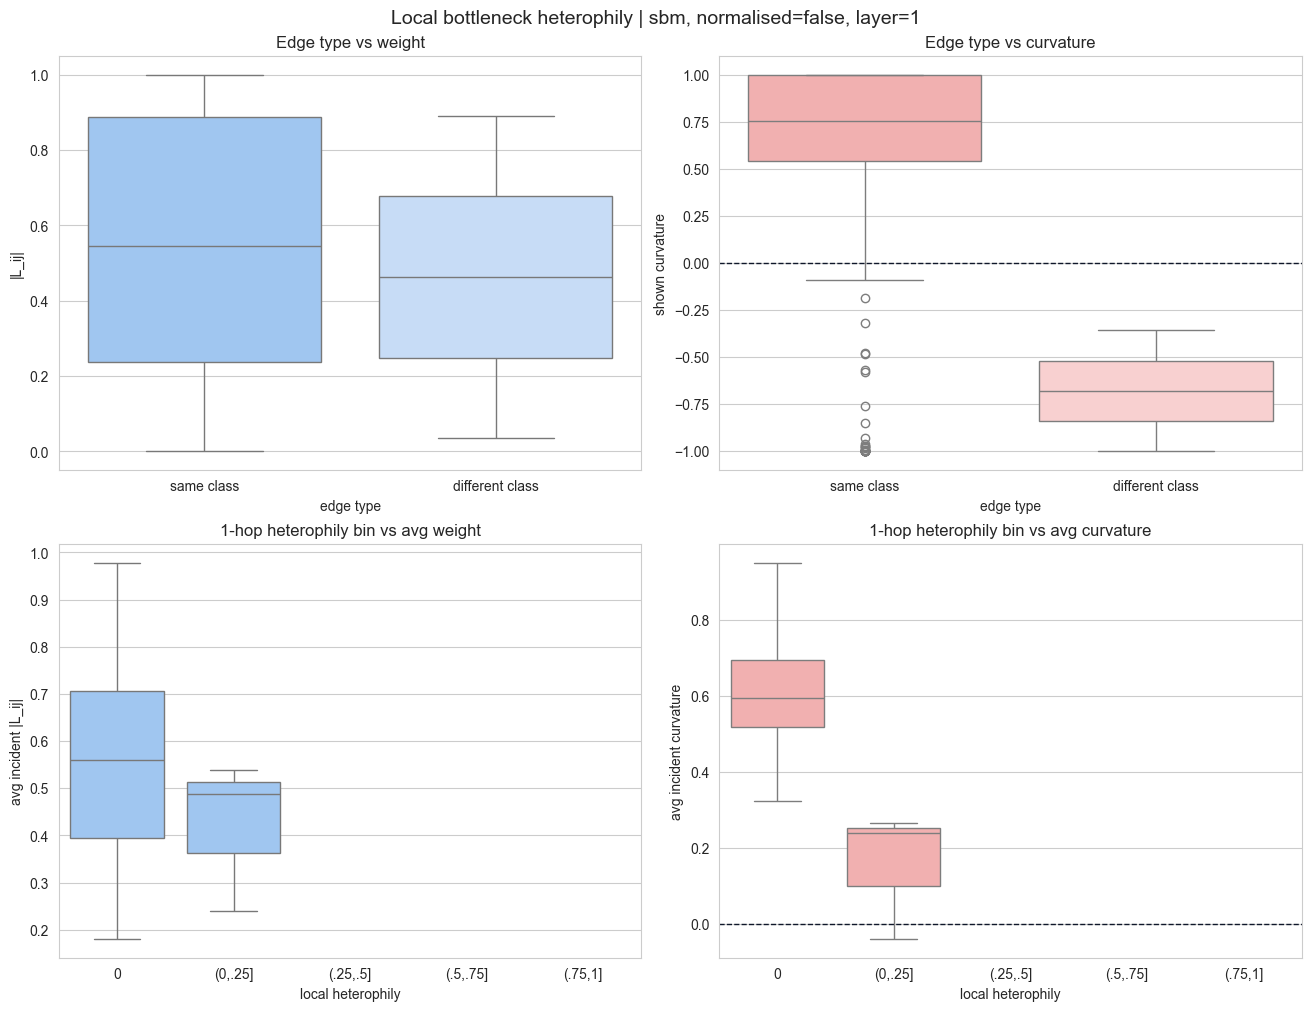

,node,class,laplacian_degree,local_heterophily,avg_1hop_weight,avg_1hop_curvature,heterophily_bin
0,0,0,12,0.083333,0.537997,0.239690,"(0,.25]"
1,1,0,6,0.000000,0.655284,0.494141,0
2,2,0,6,0.000000,0.589944,0.452355,0
3,3,0,13,0.000000,0.814010,0.593940,0
4,4,0,11,0.000000,0.551869,0.506846,0
5,5,0,13,0.000000,0.782890,0.622412,0
6,6,0,11,0.000000,0.922405,0.692708,0
7,7,0,10,0.000000,0.754572,0.488485,0
8,8,0,7,0.000000,0.770278,0.563205,0
9,9,0,9,0.000000,0.606209,0.604362,0


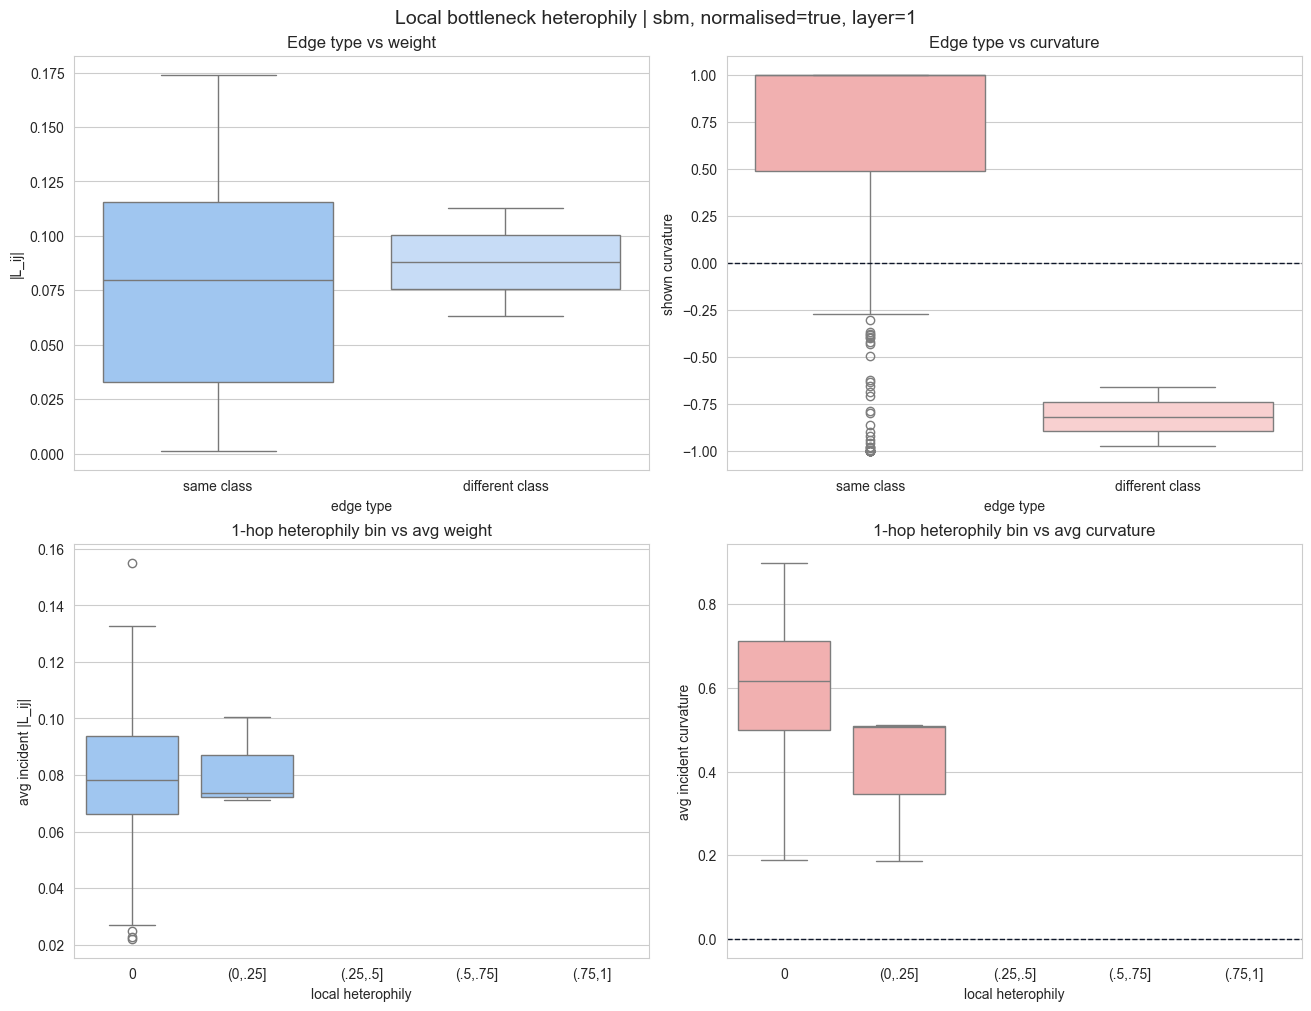

,node,class,laplacian_degree,local_heterophily,avg_1hop_weight,avg_1hop_curvature,heterophily_bin
0,0,0,12,0.083333,0.071221,0.505801,"(0,.25]"
1,1,0,6,0.000000,0.026893,0.236186,0
2,2,0,6,0.000000,0.043385,0.244116,0
3,3,0,13,0.000000,0.079144,0.822090,0
4,4,0,11,0.000000,0.074522,0.869200,0
5,5,0,13,0.000000,0.030393,0.402092,0
6,6,0,11,0.000000,0.086113,0.695444,0
7,7,0,10,0.000000,0.073568,0.555347,0
8,8,0,7,0.000000,0.075846,0.846083,0
9,9,0,9,0.000000,0.036174,0.513758,0


In [110]:
# Optional local bottleneck diagnostics by class mismatch.
def build_local_heterophily_frame(edge_df, node_df):
    rows = []
    for node, node_class in node_df[["node", "class"]].itertuples(index=False):
        incident = edge_df[(edge_df["source"] == node) | (edge_df["target"] == node)]
        rows.append({
            "node": int(node),
            "class": int(node_class),
            "laplacian_degree": int(len(incident)),
            "local_heterophily": float((~incident["same_class"]).mean()) if len(incident) else np.nan,
            "avg_1hop_weight": float(incident["weight"].mean()) if len(incident) else np.nan,
            "avg_1hop_curvature": float(incident["shown_curvature"].mean()) if len(incident) else np.nan,
        })
    local_df = pd.DataFrame(rows)
    local_df["heterophily_bin"] = pd.cut(
        local_df["local_heterophily"],
        bins=[-0.001, 0.0, 0.25, 0.5, 0.75, 1.0],
        labels=["0", "(0,.25]", "(.25,.5]", "(.5,.75]", "(.75,1]"],
    )
    return local_df


def plot_local_heterophily_analysis(edge_df, local_df, title):
    edge_view = edge_df.assign(edge_type=np.where(edge_df["same_class"], "same class", "different class"))
    fig, ax = plt.subplot_mosaic(
        [["edge_weight", "edge_curvature"], ["node_weight", "node_curvature"]],
        figsize=(13, 10), constrained_layout=True,
    )
    sns.boxplot(data=edge_view, x="edge_type", y="weight", hue="edge_type", palette=["#93c5fd", "#bfdbfe"], legend=False, ax=ax["edge_weight"])
    sns.boxplot(data=edge_view, x="edge_type", y="shown_curvature", hue="edge_type", palette=["#fca5a5", "#fecaca"], legend=False, ax=ax["edge_curvature"])
    sns.boxplot(data=local_df.dropna(subset=["heterophily_bin"]), x="heterophily_bin", y="avg_1hop_weight", color="#93c5fd", ax=ax["node_weight"])
    sns.boxplot(data=local_df.dropna(subset=["heterophily_bin"]), x="heterophily_bin", y="avg_1hop_curvature", color="#fca5a5", ax=ax["node_curvature"])
    ax["edge_weight"].set(title="Edge type vs weight", xlabel="edge type", ylabel="|L_ij|")
    ax["edge_curvature"].axhline(0, color="#0f172a", linestyle="--", linewidth=1)
    ax["edge_curvature"].set(title="Edge type vs curvature", xlabel="edge type", ylabel="shown curvature")
    ax["node_weight"].set(title="1-hop heterophily bin vs avg weight", xlabel="local heterophily", ylabel="avg incident |L_ij|")
    ax["node_curvature"].axhline(0, color="#0f172a", linestyle="--", linewidth=1)
    ax["node_curvature"].set(title="1-hop heterophily bin vs avg curvature", xlabel="local heterophily", ylabel="avg incident curvature")
    fig.suptitle(title, fontsize=14)
    plt.show()


bottleneck_local_heterophily_tables = {}
for key, edge_df in bottleneck_feature_edge_tables.items():
    node_df = bottleneck_node_tables[key]
    local_df = build_local_heterophily_frame(edge_df, node_df)
    bottleneck_local_heterophily_tables[key] = local_df
    graph, normalised, layer, fold = key
    plot_local_heterophily_analysis(edge_df, local_df, f"Local bottleneck heterophily | {graph}, normalised={normalised}, layer={layer}")
    display(local_df.head(20))
